In [1]:
import torch
import torch.nn.functional as F 
from vit_pytorch.simple_flash_attn_vit_3d import SimpleViT

import matplotlib.pyplot as plt
import numpy as np


In [20]:
v = SimpleViT(
    image_size = 128,          # image size
    frames = 32,               # number of frames
    image_patch_size = 16,     # image patch size
    frame_patch_size = 2,      # frame patch size
    num_classes = 4,
    dim = 512,
    depth = 6,
    heads = 8,
    mlp_dim = 2048,
    use_flash_attn = True,
    channels = 1
)

video = torch.randn(4, 1, 32, 32, 32) # (batch, channels, frames, height, width)

preds = v(video) # (4, #n_classes)

/home/arnaud/miniconda3/envs/mri/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [3]:
F.softmax(preds, dim = 1)

tensor([[0.2252, 0.2182, 0.3666, 0.1900],
        [0.2352, 0.2205, 0.3879, 0.1563],
        [0.2359, 0.2156, 0.3788, 0.1698],
        [0.2577, 0.2343, 0.3448, 0.1631]], grad_fn=<SoftmaxBackward0>)

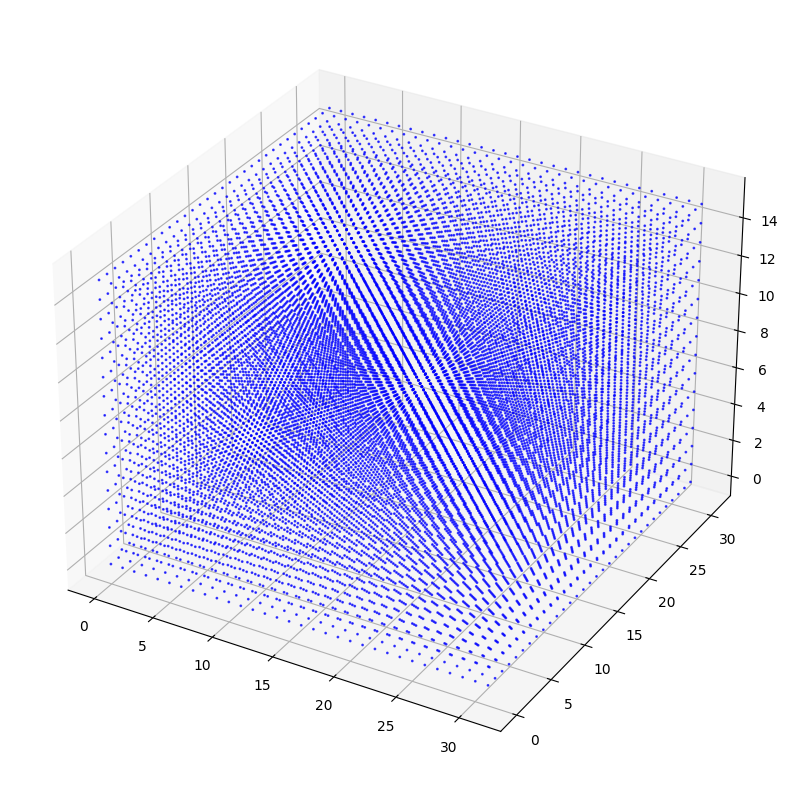

In [4]:
# PLANES
grid = torch.arange(32, dtype=torch.float32)
grid = grid.unsqueeze(0).repeat(32, 32, 1).permute(2, 0, 1)
volume = (grid < 16).float().unsqueeze(0)  # Create a binary plane in the volume

z, y, x = np.nonzero(volume[0].numpy())

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', s=1, alpha=0.7)

plt.show()


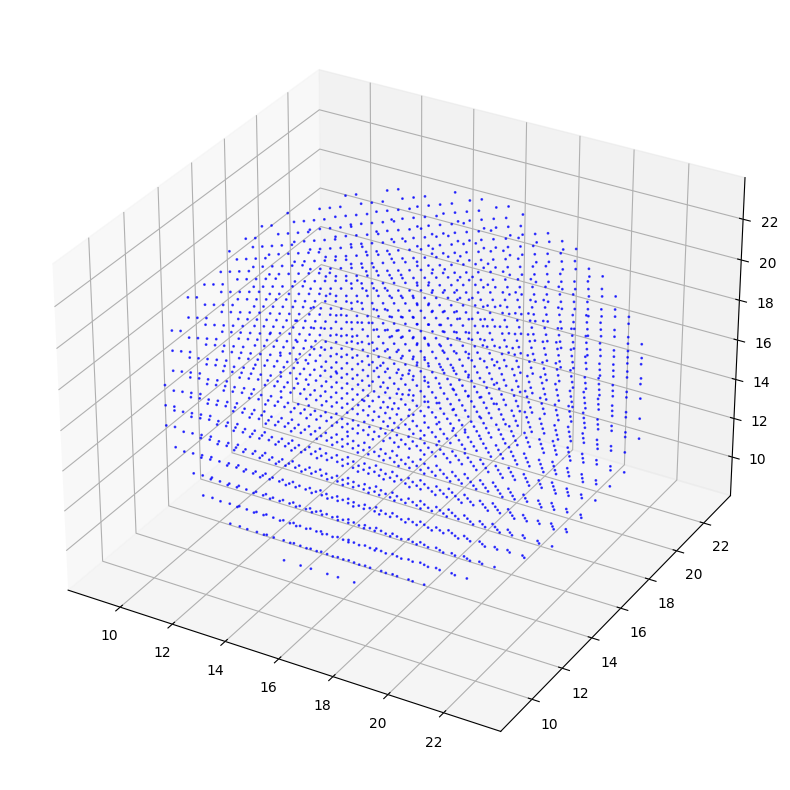

In [10]:
# SPHERE

volume_size = (32, 32, 32)
center = torch.tensor([dim // 2 for dim in volume_size], dtype=torch.float32)
grid_x, grid_y, grid_z = torch.meshgrid(
    torch.arange(0, volume_size[0], 1, dtype=torch.float32),
    torch.arange(0, volume_size[1], 1, dtype=torch.float32),
    torch.arange(0, volume_size[2], 1, dtype=torch.float32),
    indexing="ij"
)
dist = torch.sqrt((grid_x - center[0]) ** 2 +
                    (grid_y - center[1]) ** 2 +
                    (grid_z - center[2]) ** 2)
radius = volume_size[0] // 4
volume =  (dist < radius).float()

x, y, z = np.nonzero(volume.numpy())
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', s=1, alpha=0.7)
plt.show()

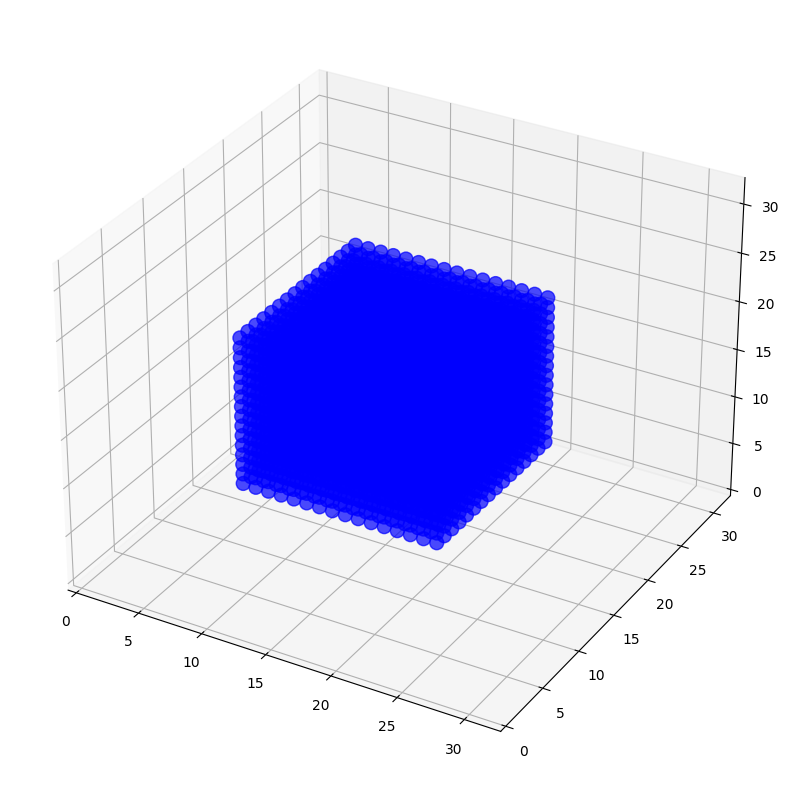

In [17]:
# CUBE 
volume_size = (32, 32, 32)
cube = torch.zeros(volume_size, dtype=torch.float32)
margin = volume_size[0] // 4
cube[margin:-margin, margin:-margin, margin:-margin] = 1

volume = cube

x, y, z = np.nonzero(volume.numpy())
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', s=100, alpha=0.7)
ax.set_xlim(0, volume_size[0])
ax.set_ylim(0, volume_size[1])
ax.set_zlim(0, volume_size[2])

plt.show()

In [45]:
from torch.utils.data import Dataset, DataLoader

class Fake3DVolumeDataset(Dataset):
    def __init__(self, num_samples=1280, volume_size=(32, 32, 32), dim=1):
        self.num_samples = num_samples
        self.volume_size = volume_size
        self.dim = dim

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate random 3D volume with proper channel dimension
        rand = torch.rand(1)
        if rand < 0.25:
            # Add channel dimension: [C, D, H, W]
            # volume = torch.rand(1, *self.volume_size)  
            volume = torch.zeros(self.dim, *self.volume_size, dtype=torch.float32)  
            label = torch.tensor(0, dtype=torch.long)
        elif 0.25 < rand < 0.5:
            volume = torch.ones(self.dim, *self.volume_size, dtype=torch.float32) 
            label = torch.tensor(1, dtype=torch.long)
        elif 0.5 < rand < 0.75:
            # cube
            volume = torch.zeros(volume_size, dtype=torch.float32)
            margin = volume_size[0] // 4
            volume[margin:-margin, margin:-margin, margin:-margin] = 1
            volume = volume.unsqueeze(0)
            label = torch.tensor(2, dtype=torch.long)
        else:
            # sphere
            center = torch.tensor([dim // 2 for dim in volume_size], dtype=torch.float32)
            grid_x, grid_y, grid_z = torch.meshgrid(
                torch.arange(0, volume_size[0], 1, dtype=torch.float32),
                torch.arange(0, volume_size[1], 1, dtype=torch.float32),
                torch.arange(0, volume_size[2], 1, dtype=torch.float32),
                indexing="ij"
                )
            dist = torch.sqrt((grid_x - center[0]) ** 2 +
                                (grid_y - center[1]) ** 2 +
                                (grid_z - center[2]) ** 2)
            radius = volume_size[0] // 4
            volume =  (dist < radius).float()
            volume = volume.unsqueeze(0)
            label = torch.tensor(3, dtype=torch.long)
        return volume, label

# Instantiate the dataset
dataset = Fake3DVolumeDataset()

# Create a DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# # Example of iterating through the dataloader
for batch_idx, (volumes, labels) in enumerate(dataloader):
    print(f"Batch {batch_idx}:")
    print(f"Volumes shape: {volumes.shape}")
    print(f"Labels: {labels}")

Batch 0:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([0, 1])
Batch 1:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([3, 3])
Batch 2:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([3, 2])
Batch 3:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([1, 3])
Batch 4:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([2, 1])
Batch 5:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([3, 3])
Batch 6:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([3, 3])
Batch 7:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([3, 2])
Batch 8:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([1, 0])
Batch 9:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([1, 3])
Batch 10:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([0, 1])
Batch 11:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels: tensor([2, 2])
Batch 12:
Volumes shape: torch.Size([2, 1, 32, 32, 32])
Labels

In [47]:
# next(iter(dataloader))

In [46]:
import torch.nn as nn

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(v.parameters(), lr=1e-4)

# Training loop
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch_idx, (volumes, labels) in enumerate(dataloader):
        volumes = volumes.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(volumes)
        # print(outputs, labels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 1 == 0:
            print(f'Batch {batch_idx}, Loss: {loss.item():.4f}')
    
    return total_loss / len(dataloader)

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_epoch(v.to(device), dataloader, optimizer, loss_fn, device)
    # test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Batch 0, Loss: 1.3009
Batch 1, Loss: 0.0002
Batch 2, Loss: 0.0002
Batch 3, Loss: 2.1524
Batch 4, Loss: 0.0002
Batch 5, Loss: 1.4405
Batch 6, Loss: 0.7457
Batch 7, Loss: 0.3733
Batch 8, Loss: 0.2806
Batch 9, Loss: 0.7629
Batch 10, Loss: 0.7893
Batch 11, Loss: 0.5611
Batch 12, Loss: 0.6990
Batch 13, Loss: 0.7060
Batch 14, Loss: 0.2066
Batch 15, Loss: 0.1355
Batch 16, Loss: 0.9565
Batch 17, Loss: 1.0289
Batch 18, Loss: 0.7811
Batch 19, Loss: 0.0001
Batch 20, Loss: 0.3345
Batch 21, Loss: 0.0001
Batch 22, Loss: 0.0951
Batch 23, Loss: 0.0954
Batch 24, Loss: 0.0223
Batch 25, Loss: 0.0001
Batch 26, Loss: 2.2681
Batch 27, Loss: 4.2446
Batch 28, Loss: 1.5743
Batch 29, Loss: 1.0068
Batch 30, Loss: 0.7452
Batch 31, Loss: 0.2583
Batch 32, Loss: 0.8308
Batch 33, Loss: 0.2234
Batch 34, Loss: 0.9789
Batch 35, Loss: 0.7200
Batch 36, Loss: 0.4033
Batch 37, Loss: 0.5743
Batch 38, Loss: 0.5237
Batch 39, Loss: 0.6954
Batch 40, Loss: 0.2161
Batch 41, Loss: 0.8052
Batc

In [47]:
v(next(iter(dataloader))[0].to('cuda:1')), next(iter(dataloader))[1]

(tensor([[-3.8547, -3.7452,  9.5307, -5.0776],
         [-2.7885, -2.7596, -3.1300, 11.8760]], device='cuda:1',
        grad_fn=<AddmmBackward0>),
 tensor([0, 0]))

In [48]:
count = 0
for batch_idx, (volumes, labels) in enumerate(dataloader):
    print(out:=v(volumes.to("cuda:1")))
    print(torch.softmax(out, 1))
    predicted = torch.argmax(out, 1)
    print(predicted)
    print(labels)
    for yhat, y in zip(predicted, labels):
        if yhat.item() == y.item():
            count += 1

count / (len(dataloader) * dataloader.batch_size)

tensor([[-2.7885, -2.7596, -3.1300, 11.8760],
        [-2.7885, -2.7596, -3.1300, 11.8760]], device='cuda:1',
       grad_fn=<AddmmBackward0>)
tensor([[4.2781e-07, 4.4040e-07, 3.0406e-07, 1.0000e+00],
        [4.2781e-07, 4.4040e-07, 3.0406e-07, 1.0000e+00]], device='cuda:1',
       grad_fn=<SoftmaxBackward0>)
tensor([3, 3], device='cuda:1')
tensor([3, 3])
tensor([[ 1.9309,  2.3296, -6.9384, -9.1656],
        [ 1.9309,  2.3296, -6.9384, -9.1656]], device='cuda:1',
       grad_fn=<AddmmBackward0>)
tensor([[4.0161e-01, 5.9832e-01, 5.6482e-05, 6.0905e-06],
        [4.0161e-01, 5.9832e-01, 5.6482e-05, 6.0905e-06]], device='cuda:1',
       grad_fn=<SoftmaxBackward0>)
tensor([1, 1], device='cuda:1')
tensor([1, 1])
tensor([[-2.7885, -2.7596, -3.1300, 11.8760],
        [ 1.9309,  2.3296, -6.9384, -9.1656]], device='cuda:1',
       grad_fn=<AddmmBackward0>)
tensor([[4.2781e-07, 4.4040e-07, 3.0406e-07, 1.0000e+00],
        [4.0161e-01, 5.9832e-01, 5.6482e-05, 6.0905e-06]], device='cuda:1',
     

0.73984375

2

In [30]:
from torchvision.models import swin_v2_b
import torch.nn as nn

swin = swin_v2_b()
# swin

In [39]:
dataset = Fake3DVolumeDataset(64, (32,32), dim = 3)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [40]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(v.parameters(), lr=1e-4)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch_idx, (volumes, labels) in enumerate(dataloader):
        volumes = volumes.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(volumes)
        # print(outputs, labels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 1 == 0:
            print(f'Batch {batch_idx}, Loss: {loss.item():.4f}')
    
    return total_loss / len(dataloader)

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_epoch(swin.to(device), dataloader, optimizer, loss_fn, device)
    # test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
Batch 0, Loss: 8.0029
Batch 1, Loss: 7.5696
Batch 2, Loss: 8.0430
Batch 3, Loss: 8.3429
Batch 4, Loss: 6.9979
Batch 5, Loss: 6.8085
Batch 6, Loss: 8.7005
Batch 7, Loss: 8.9686
Batch 8, Loss: 7.4047
Batch 9, Loss: 7.9322
Batch 10, Loss: 7.0478
Batch 11, Loss: 7.5957
Batch 12, Loss: 7.2658
Batch 13, Loss: 7.1233
Batch 14, Loss: 7.3579
Batch 15, Loss: 7.5520
Batch 16, Loss: 7.7608
Batch 17, Loss: 7.5967
Batch 18, Loss: 7.4117
Batch 19, Loss: 6.8775
Batch 20, Loss: 6.9155
Batch 21, Loss: 6.7995
Batch 22, Loss: 6.8278
Batch 23, Loss: 7.3257
Batch 24, Loss: 7.1344
Batch 25, Loss: 7.7315
Batch 26, Loss: 7.1242
Batch 27, Loss: 7.2363
Batch 28, Loss: 7.6741
Batch 29, Loss: 6.9026
Batch 30, Loss: 6.8917
Batch 31, Loss: 8.1839
Batch 32, Loss: 8.0924
Batch 33, Loss: 7.3985
Batch 34, Loss: 7.6306
Batch 35, Loss: 7.3225
Batch 36, Loss: 6.6180
Batch 37, Loss: 6.1519
Batch 38, Loss: 7.6678
Batch 39, Loss: 7.7521
Batch 40, Loss: 6.6121
Batch 41, Loss: 7.2214
Batc

# Open 3D data

In [1]:
import open3d as o3d
import numpy as np 

dataset = o3d.data.BunnyMesh()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
pcd = o3d.io.read_triangle_mesh(dataset.path)
pcd

TriangleMesh with 35947 points and 69451 triangles.

In [77]:
verts = np.asarray(pcd.vertices)
tris = np.asarray(pcd.triangles).shape

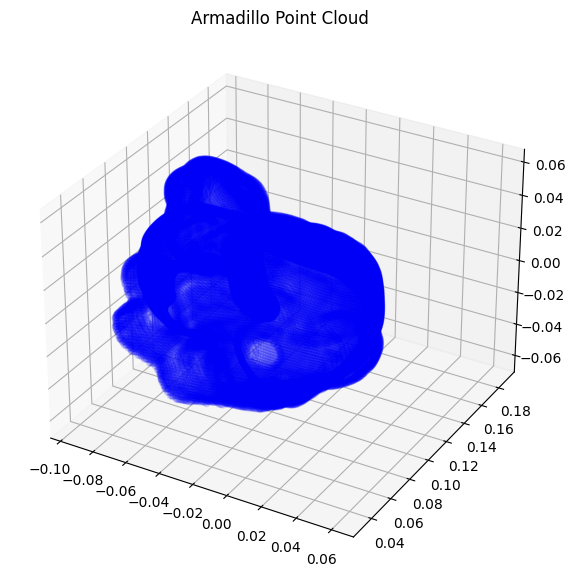

In [78]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(verts[:, 0], 
            verts[:, 1], 
            verts[:, 2], 
            c='b', alpha=0.1)
plt.title('Armadillo Point Cloud')
plt.show()

In [5]:
import open3d as o3d
# Monkey-patch torch.utils.tensorboard.SummaryWriter
from open3d.visualization.tensorboard_plugin import summary
# Utility function to convert Open3D geometry to a dictionary format
from open3d.visualization.tensorboard_plugin.util import to_dict_batch
from torch.utils.tensorboard import SummaryWriter

cube = o3d.geometry.TriangleMesh.create_box(1, 2, 4)
cube.compute_vertex_normals()
cylinder = o3d.geometry.TriangleMesh.create_cylinder(radius=1.0,
                                                     height=2.0,
                                                     resolution=20,
                                                     split=4)
cylinder.compute_vertex_normals()
colors = [(1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0)]

2024-12-16 11:07:26.359391: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-16 11:07:26.372102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734343646.386036 3509325 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734343646.390279 3509325 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-16 11:07:26.405360: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [6]:
logdir = "demo_logs/pytorch/small_scale"
writer = SummaryWriter(logdir)
for step in range(3):
    cube.paint_uniform_color(colors[step])
    writer.add_3d('cube', to_dict_batch([cube]), step=step)
    cylinder.paint_uniform_color(colors[step])
    writer.add_3d('cylinder', to_dict_batch([cylinder]), step=step)

## 3D semantic seg

In [ ]:
writer = SummaryWriter(join(BASE_LOGDIR, "semseg-example"))
for step in range(len(pcd_files)):
    # We will pretend these are the inputs and outputs of a Semantic
    # Segmentation model
    # float, shape (N, 3), or (B, N, 3) for a batch
    points = np.load(pcd_files[step])
    # int, shape (N, 1), or (B, N, 1) for a batch
    labels = np.load(label_files[step])
    # We can also visualize noisy scores (car, road, vegetation)
    scores = np.hstack((labels == 1, labels == 9, labels == 15))
    scores = np.clip(scores + rng.normal(0., 0.05, size=scores.shape), 0.,
                     1.)
    # and outputs of some pretend network layers. The first 3 dimensions
    # can be visualized as RGB colors. Here we will use distances from the
    # centroids of (all points, road, vegetation).
    centroid_all = np.mean(points, axis=0)
    d_all = np.linalg.norm(points - centroid_all, axis=1)
    centroid_road = np.mean(points[np.squeeze(labels) == 9, :], axis=0)
    d_road = np.linalg.norm(points - centroid_road, axis=1)
    centroid_vegetation = np.mean(points[np.squeeze(labels) == 15, :],
                                  axis=0)
    d_vegetation = np.linalg.norm(points - centroid_vegetation, axis=1)
    features = np.stack((d_all, d_road, d_vegetation), axis=1)

    # You can use Torch tensors directly too.
    # Prefix the data with "vertex_" for per vertex data.
    writer.add_3d(
        "semantic_segmentation",
        {
            "vertex_positions": points,  # (N, 3)
            "vertex_labels": labels,  # (N, 1)
            "vertex_scores": scores,  # (N, 3)
            "vertex_features": features  # (N, 3)
        },
        step,
        label_to_names=SEMANTIC_KITTI_LABELS)